# Polynomial Features - Classification Companion Notebook

This notebook is the practical code companion for the classification part of [`lecture_notes/13_polynomial_features.pdf`](../../lecture_notes/13_polynomial_features.pdf). The goal is to show how logistic regression can produce non-linear decision boundaries once the input space is expanded with polynomial features.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42
rng = np.random.default_rng(SEED)


This setup cell imports the tools used throughout the notebook. The dataset will be synthetic so that the geometric meaning of the resulting decision boundaries is easy to visualize.


## A Non-Linearly Separable Toy Dataset

We construct a binary classification problem in which one class tends to occupy the center of the plane and the other class tends to occupy the outer ring.


In [2]:
X = rng.normal(0, 1, size=(250, 2))
y = ((X[:, 0] ** 2 + X[:, 1] ** 2) < 1.8).astype(int)


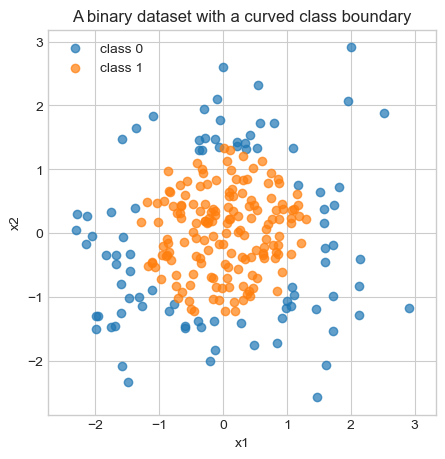

In [3]:
plt.figure(figsize=(5, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.7, label="class 0")
plt.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.7, label="class 1")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("A binary dataset with a curved class boundary")
plt.legend()
plt.axis("equal")
plt.show()


A straight line is not a good separator for this dataset. That is exactly why vanilla logistic regression struggles here: the issue is not poor optimization, but limited expressiveness in the original feature space.


In [4]:
def plot_decision_boundary(model, X, y, title):
    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, 300),
        np.linspace(x1_min, x1_max, 300),
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.7, label="class 0")
    plt.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.7, label="class 1")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()


This helper function is used repeatedly in the notebook. It keeps the plots focused on the question that matters here: what kind of decision boundary does the model induce in the original input space?


## Vanilla Logistic Regression

We first fit logistic regression directly on the original two coordinates.


In [5]:
log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X, y)
print("training accuracy:", round(log_reg.score(X, y), 4))


training accuracy: 0.648


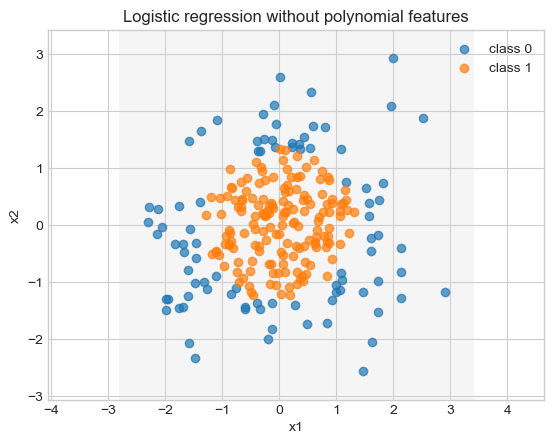

In [6]:
plot_decision_boundary(log_reg, X, y, "Logistic regression without polynomial features")


The boundary is linear because the model is linear in the original coordinates. Even if the classifier is tuned well, it still cannot create the curved separator that this dataset calls for.


## Logistic Regression After Polynomial Expansion

Now the learning algorithm stays the same, but the input representation changes.


In [7]:
def make_poly_logistic(degree):
    return Pipeline([
        ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=5000)),
    ])


poly_models = {}
for degree in [2, 3]:
    model = make_poly_logistic(degree)
    model.fit(X, y)
    poly_models[degree] = model
    print(f"degree {degree} training accuracy:", round(model.score(X, y), 4))


degree 2 training accuracy: 0.984
degree 3 training accuracy: 0.984


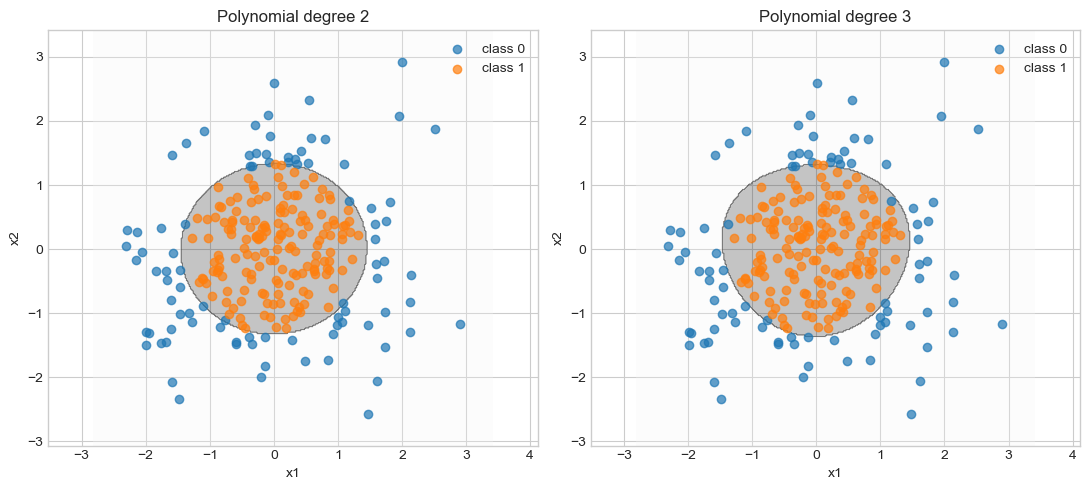

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, degree in zip(axes, [2, 3]):
    model = poly_models[degree]
    x0_min, x0_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    x1_min, x1_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x0_min, x0_max, 300), np.linspace(x1_min, x1_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, zz, alpha=0.25)
    ax.scatter(X[y == 0, 0], X[y == 0, 1], alpha=0.7, label="class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], alpha=0.7, label="class 1")
    ax.set_title(f"Polynomial degree {degree}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")
    ax.axis("equal")
    ax.legend()

plt.tight_layout()
plt.show()


The resulting decision boundaries are no longer linear in the original plane. This is the key conceptual point: the classifier is still logistic regression, but the expanded feature space lets it express much more complex geometry.


In [10]:
import pandas as pd
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_poly2 = poly2.fit_transform(X[:5])
pd.DataFrame(X_poly2, columns=poly2.get_feature_names_out(["x1", "x2"]))


,x1,x2,x1^2,x1 x2,x2^2
0,0.304717,-1.039984,0.092852,-0.316901,1.081567
1,0.750451,0.940565,0.563177,0.705848,0.884662
2,-1.951035,-1.302180,3.806538,2.540598,1.695671
3,0.127840,-0.316243,0.016343,-0.040429,0.100009
4,-0.016801,-0.853044,0.000282,0.014332,0.727684


This small table makes the transformed representation visible. In two dimensions, degree 2 already introduces `x1^2`, `x1 x2`, and `x2^2`, which is enough to express circular or elliptical patterns that are impossible for vanilla logistic regression.
